# Analisi dei dati — v2

Ricostruzione dell'analisi partendo dai log JSON in `results/logs/`.

Struttura su disco:

```
results/logs/<goal_dir>/<algorithm>/<algo>_<maze>_<timestamp>.json
    goal_dir   : one_goal | two_goals | three_goals | four_goals
    algorithm  : astar | dstar_lite
```

Ogni JSON è una singola run e contiene sia scalari (mosse, tempi, replanning…)
sia strutture (matrici `wall_matrix`/`visit_matrix`, lista `replanning_events`,
`scenario` con i goal). Nota: la stessa combinazione (goal_dir, algoritmo, maze)
può avere più run con timestamp diversi — vengono tenute tutte.

In [20]:
import json
from pathlib import Path

import pandas as pd

LOGS_DIR = Path.cwd().parent / "results" / "logs"

# Campi scalari -> colonne del DataFrame. Le strutture (wall_matrix, visit_matrix,
# replanning_events, scenario) restano fuori: si recuperano da raw_logs via run_id.
SCALAR_FIELDS = [
    "algorithm",
    "maze",
    "goal_count",
    "timestamp",
    "total_moves",
    "forward_moves",
    "turns",
    "distinct_cells_visited",
    "total_visits",
    "execution_time_s",
    "total_replanning_events",
    "cumulative_planning_time_s",
    "cumulative_nodes_expanded",
]

rows, raw_logs = [], {}

for path in sorted(LOGS_DIR.rglob("*.json")):
    log = json.loads(path.read_text())
    goal_dir = path.relative_to(LOGS_DIR).parts[0]   # one_goal, two_goals, ...
    # NB: lo sweep -k salva k=1..4 con lo STESSO nome file in cartelle goal
    # diverse, quindi path.stem NON è univoco: il goal_dir va incluso nel run_id.
    run_id = f"{goal_dir}/{path.stem}"
    raw_logs[run_id] = log                    # JSON completo (matrici, eventi, scenario)
    rows.append({
        "run_id":   run_id,
        "goal_dir": goal_dir,
        **{f: log.get(f) for f in SCALAR_FIELDS},
    })

runs = pd.DataFrame(rows).set_index("run_id")
runs = runs.sort_values(["goal_count", "maze", "algorithm", "timestamp"])

print(f"run caricate: {len(runs)}")
print("algoritmi:", sorted(runs['algorithm'].unique()))
print("maze:     ", sorted(runs['maze'].unique()))
print("goal:     ", sorted(runs['goal_count'].unique()))
runs.head()

run caricate: 493
algoritmi: ['astar', 'dstar_lite']
maze:      ['00japan', '1stworld', '2008japan', '2008robotic', '2009japan', '2011robotic', '2011uk-techfest', '2012japan-eq', '2012uk-techfest', '2013apec', '2013japan', '2014apec', '2014japan', '2015apec', '2015japan', '2016apec', '2017apec', '2017japan', '2018apec', '82japx', '82us', '83jap', '83us', '84japx', '85japx', '85usa', '86', '86jap', '86us', '87iee', '87sin', '88iee', '88jap', '88lon', '88mtl', '88sin', '88us', '89ape', '89iee', '89sina1', '90lon', '90tor', '91hon', '91japq', '91tor', '92bos', '92lon', '93apec', '93japx', '96japx', 'j1', 'loop', 'museum', 'test1', 'zigzag']
goal:      [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,goal_dir,algorithm,maze,goal_count,timestamp,total_moves,forward_moves,turns,distinct_cells_visited,total_visits,execution_time_s,total_replanning_events,cumulative_planning_time_s,cumulative_nodes_expanded
run_id,,,,,,,,,,,,,,
one_goal/astar_00japan_20260721_230852,one_goal,astar,00japan,1,20260721_230852,140,88,52,85,89,0.020325,35,0.006508,378
one_goal/dstar_lite_00japan_20260721_230852,one_goal,dstar_lite,00japan,1,20260721_230852,140,88,52,85,89,0.008180,34,0.001665,228
one_goal/astar_1stworld_20260721_230853,one_goal,astar,1stworld,1,20260721_230853,167,113,54,105,114,0.067530,52,0.023057,704
one_goal/dstar_lite_1stworld_20260721_230853,one_goal,dstar_lite,1stworld,1,20260721_230853,167,113,54,105,114,0.018757,37,0.003094,366
one_goal/astar_2008japan_20260721_230853,one_goal,astar,2008japan,1,20260721_230853,253,168,85,154,169,0.036747,68,0.012816,2622


## Setup: sorgenti e plotting

Import dei moduli `src` (parsing dei maze, piazzamento dei goal) e di
numpy/matplotlib, usati dalle sezioni di visualizzazione (matrici di detour,
heatmap).

In [21]:
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.parser.maze_parser import parse_maze
from src.goal_placement import scenario_goals

MAZES_DIR = REPO_ROOT / "mazes" / "txt"
START = (0, 0)

### Come vengono scelti i goal — heatmap dei punteggi

Per un maze a scelta (impostabile nella cella sotto) si mostrano, come **heatmap
seaborn**, le mappe di punteggio che `place_goals` usa per scegliere i goal — una
heatmap per ogni goal, così si vede a colpo d'occhio **quale cella viene presa a
ogni passo**.

Ogni heatmap è la mappa di punteggio il cui **massimo** (cella evidenziata in
verde) è il goal selezionato a quel passo:
1. **goal 1** → detour dalla partenza;
2. **goal k (k ≥ 2)** → minimo cella-per-cella dei detour da partenza e da tutti i
   goal già piazzati; il suo massimo è il goal *k*.

I goal scelti nei passi precedenti restano segnati (contorno grigio) per seguire
l'accumulo. Le celle vuote sono non candidabili (la partenza o celle
irraggiungibili). L'origine `(0,0)` è in **basso a sinistra**.

> Lo scenario classico *k = 1* è saltato di proposito: il goal è fisso al centro del
> maze `(w // 2 - 1, h // 2 - 1)` e non deriva dalle matrici di detour, quindi non
> compare in questa sequenza.

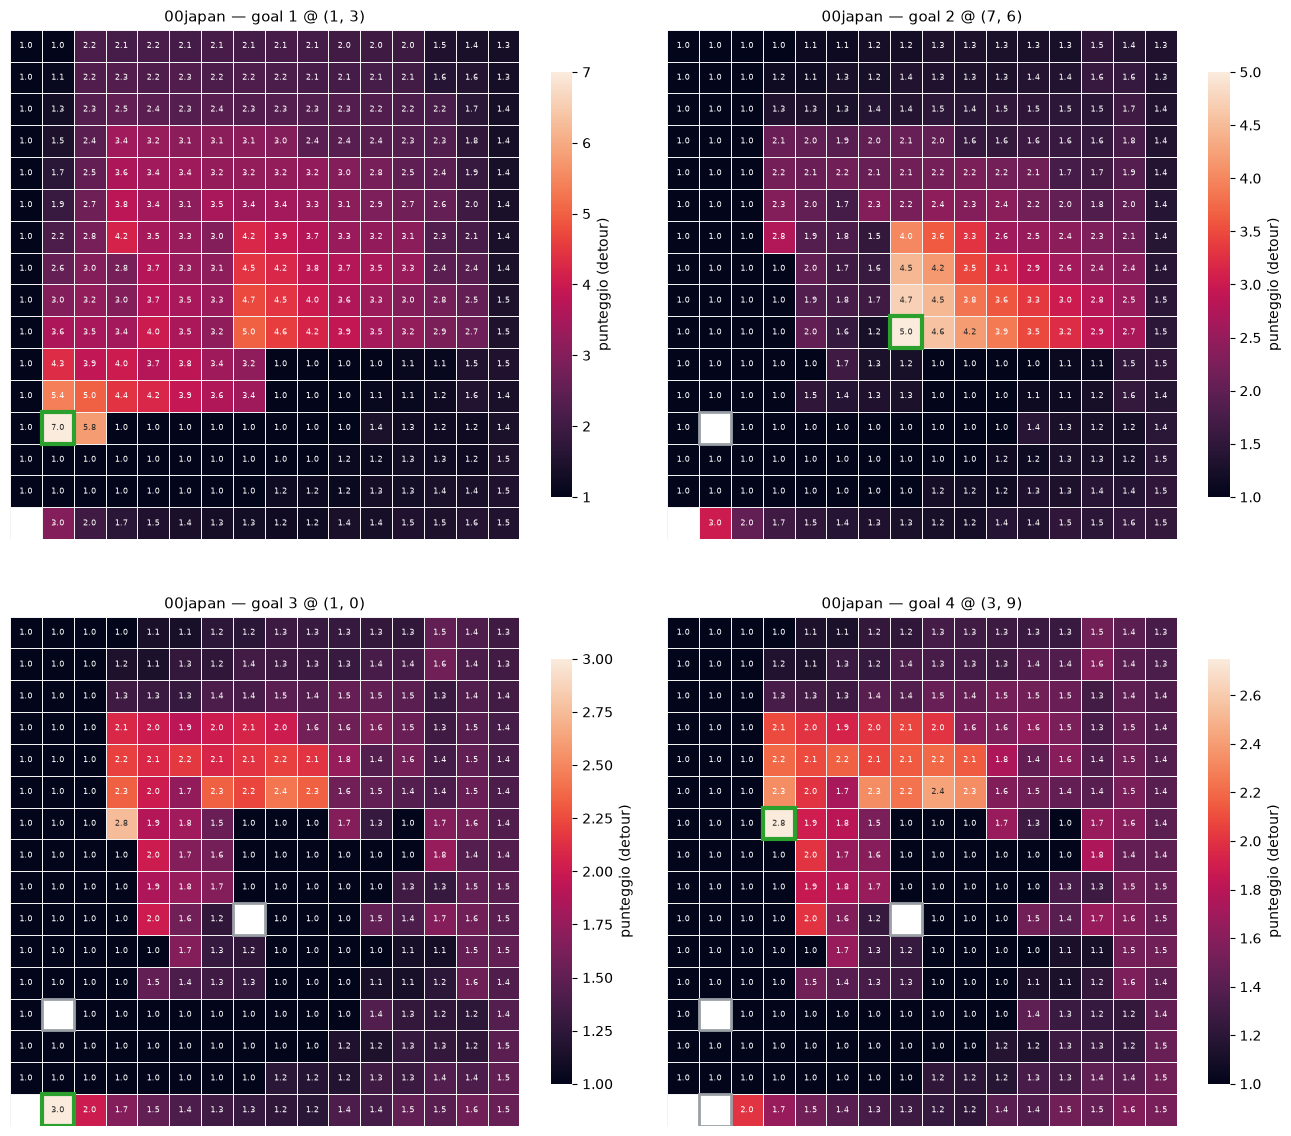

In [38]:
import seaborn as sns

from src.goal_placement import (
    bfs_distance_map, detour_map, argmax_cell, _combine_min,
)


def goal_score_panels(wall_matrix, width, height, start, k):
    """Mappa di punteggio che seleziona ogni goal 1..k di place_goals.

    Restituisce una lista di (i, score_map, goal, prev_goals): al passo i la
    score_map è quella il cui argmax è `goal`; prev_goals sono i goal scelti ai
    passi precedenti (per contestualizzare l'accumulo).
    """
    det_start = detour_map(bfs_distance_map(wall_matrix, width, height, start),
                           start, width, height)
    det_maps = [det_start]
    excluded = {start}
    chosen = []
    panels = []
    for i in range(1, k + 1):
        score_map = det_start if len(det_maps) == 1 else _combine_min(det_maps, width, height)
        goal, _ = argmax_cell(score_map, width, height, excluded)
        panels.append((i, score_map, goal, list(chosen)))
        excluded.add(goal)
        chosen.append(goal)
        det_maps.append(detour_map(bfs_distance_map(wall_matrix, width, height, goal),
                                   goal, width, height))
    return panels


def show_heatmap(ax, score_map, goal, prev_goals, title):
    """Heatmap seaborn della mappa di punteggio; goal scelto in verde, i goal
    dei passi precedenti con contorno grigio. y=0 in basso."""
    m = np.array(score_map, dtype=float)
    h, w = m.shape
    flip = m[::-1]                       # riga 0 (y=0) va in basso
    mask = np.isnan(flip)
    labels = np.where(mask, "", np.round(flip, 1).astype("U8"))
    sns.heatmap(flip, ax=ax, cmap="rocket", mask=mask,
                annot=labels, fmt="", annot_kws={"fontsize": 6},
                cbar=True, cbar_kws={"shrink": .7, "label": "punteggio (detour)"},
                linewidths=.5, linecolor="#f2f2f2",
                square=True, xticklabels=False, yticklabels=False)
    for px, py in prev_goals:            # goal gia' piazzati: contorno grigio
        ax.add_patch(plt.Rectangle((px, h - 1 - py), 1, 1, fill=False,
                                   edgecolor="#9aa0a6", lw=2))
    gx, gy = goal                        # goal scelto a questo passo: verde
    ax.add_patch(plt.Rectangle((gx, h - 1 - gy), 1, 1, fill=False,
                               edgecolor="#2ca02c", lw=3))
    ax.set_title(title, fontsize=11)


# --- scegli qui il maze e quanti goal ricostruire (k >= 2) ---
MAZE = "00japan"
K = 4

wm, w, h = parse_maze(str(MAZES_DIR / f"{MAZE}.txt"))
panels = goal_score_panels(wm, w, h, START, K)

ncols = 2
nrows = (len(panels) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * (0.32 * w + 1.5), nrows * (0.32 * h + 1)))
for ax, (i, score_map, goal, prev_goals) in zip(axes.flat, panels):
    show_heatmap(ax, score_map, goal, prev_goals,
                 f"{MAZE} — goal {i} @ {goal}")
for ax in axes.flat[len(panels):]:       # spegni eventuali riquadri in eccesso
    ax.axis("off")
fig.tight_layout()
plt.show()

## Asse 1 — Costo computazionale del replanning

Confronto A\* vs D\*-Lite sul costo di ripianificazione, aggregato **su tutti i
maze** e raggruppato per numero di goal *k*. Ogni barra è la **media sui maze**,
l'error bar è la **deviazione standard tra i maze** (dispersione dovuta alla diversa
difficoltà dei labirinti, **non** rumore di misura: le run sono deterministiche).

Metrica principale: `cumulative_nodes_expanded` (nodi totali espansi dal
pianificatore). Ci si aspetta che D\*-Lite, riusando il calcolo tra una
ripianificazione e l'altra, espanda meno nodi e scali meglio al crescere di k.

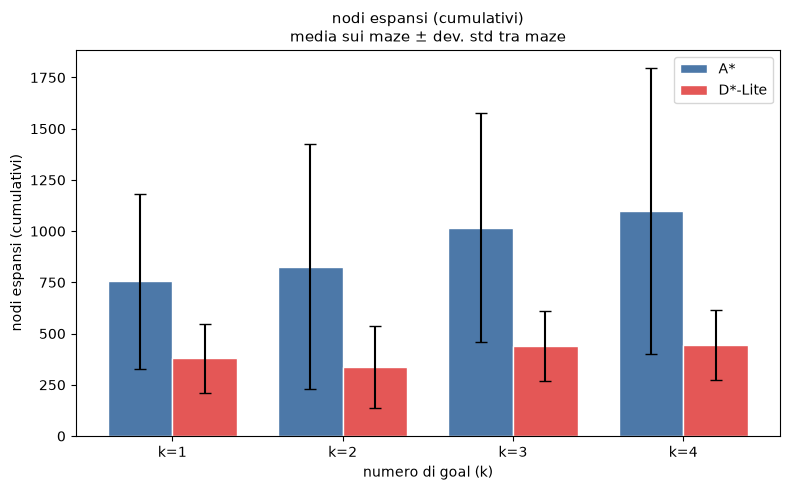

In [23]:
# Un valore per (maze, algoritmo, k), aggregando le run ripetute con la MEDIANA.
# Per le metriche deterministiche (nodi, mosse, ...) è un no-op: le run ripetute
# sono identiche. Per i tempi di macchina attenua gli outlier da carico di sistema.
per_cell = runs.reset_index().groupby(
    ["maze", "algorithm", "goal_count"], as_index=False
).median(numeric_only=True)

ALGO_ORDER = ["astar", "dstar_lite"]
ALGO_LABEL = {"astar": "A*", "dstar_lite": "D*-Lite"}
ALGO_COLOR = {"astar": "#4c78a8", "dstar_lite": "#e45756"}


def grouped_bars_by_k(metric, ylabel, ax=None):
    """Barre affiancate A*/D*-Lite per ogni k: media sui maze ± deviazione std."""
    ks = sorted(per_cell["goal_count"].unique())
    stat = per_cell.groupby(["goal_count", "algorithm"])[metric].agg(["mean", "std"])
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(ks))
    width = 0.38
    for i, algo in enumerate(ALGO_ORDER):
        means = [stat["mean"].get((k, algo), np.nan) for k in ks]
        stds = [stat["std"].get((k, algo), np.nan) for k in ks]
        ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4,
               label=ALGO_LABEL[algo], color=ALGO_COLOR[algo], edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={k}" for k in ks])
    ax.set_xlabel("numero di goal (k)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\nmedia sui maze \u00b1 dev. std tra maze", fontsize=11)
    ax.legend()
    return ax


grouped_bars_by_k("cumulative_nodes_expanded", "nodi espansi (cumulativi)")
plt.tight_layout()
plt.show()

### Costo in tempo — planning time

Stessa struttura del grafico dei nodi, ma con `cumulative_planning_time_s` sulle
ordinate (tutti i maze inclusi). Il confronto col grafico sopra mostra un
**ribaltamento**: D\*-Lite espande **meno nodi** ma impiega **più tempo di
pianificazione**. Il motivo è il costo per nodo: la macchineria incrementale di
D\*-Lite (coda di priorità con chiavi `g`/`rhs`, aggiornamenti) ha un overhead
costante molto più alto per singolo nodo.

> Il tempo è **wall-clock, machine-dependent**: riflette *questa* implementazione
> Python, non gli algoritmi in astratto. I nodi espansi restano la misura
> intrinseca dell'algoritmo; il tempo è il costo pratico nel nostro codice.

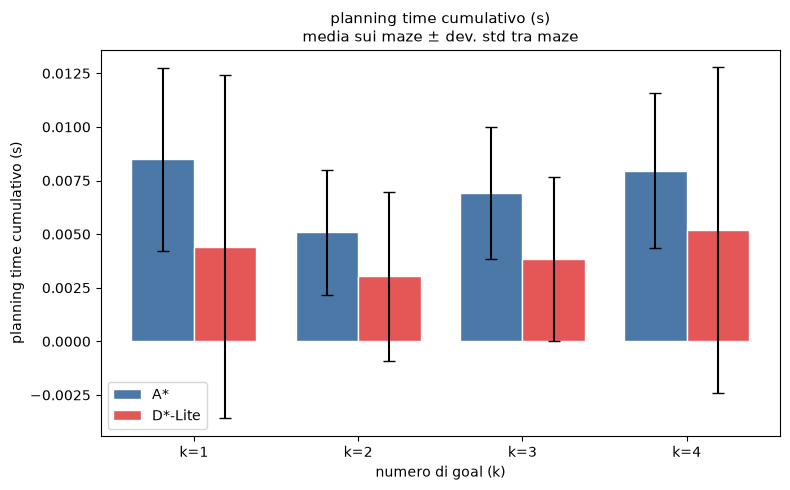

In [24]:
grouped_bars_by_k("cumulative_planning_time_s", "planning time cumulativo (s)")
plt.tight_layout()
plt.show()

### Nodi espansi vs distanza residua

Relazione **per-evento** tra il costo di ricerca (`nodes_expanded`) e la distanza
residua dal goal (`residual_distance`), un facet per numero di goal *k*.

Teniamo solo la **fascia densa** (distanza residua \u2264 30): oltre quella soglia gli
eventi sono pochissimi (doppie cifre) e la media non sarebbe affidabile. Su questa
fascia sovrapponiamo il **trend con regressione lineare ai minimi quadrati**
(`order=1`) con banda di confidenza al 95%; lo scatter tenue mostra la dispersione
reale dei dati.

A ogni k la pendenza di A\* è maggiore di quella di D\*-Lite: A\* espande più nodi a
parità di distanza dal goal, e il divario cresce allontanandosi dal goal.

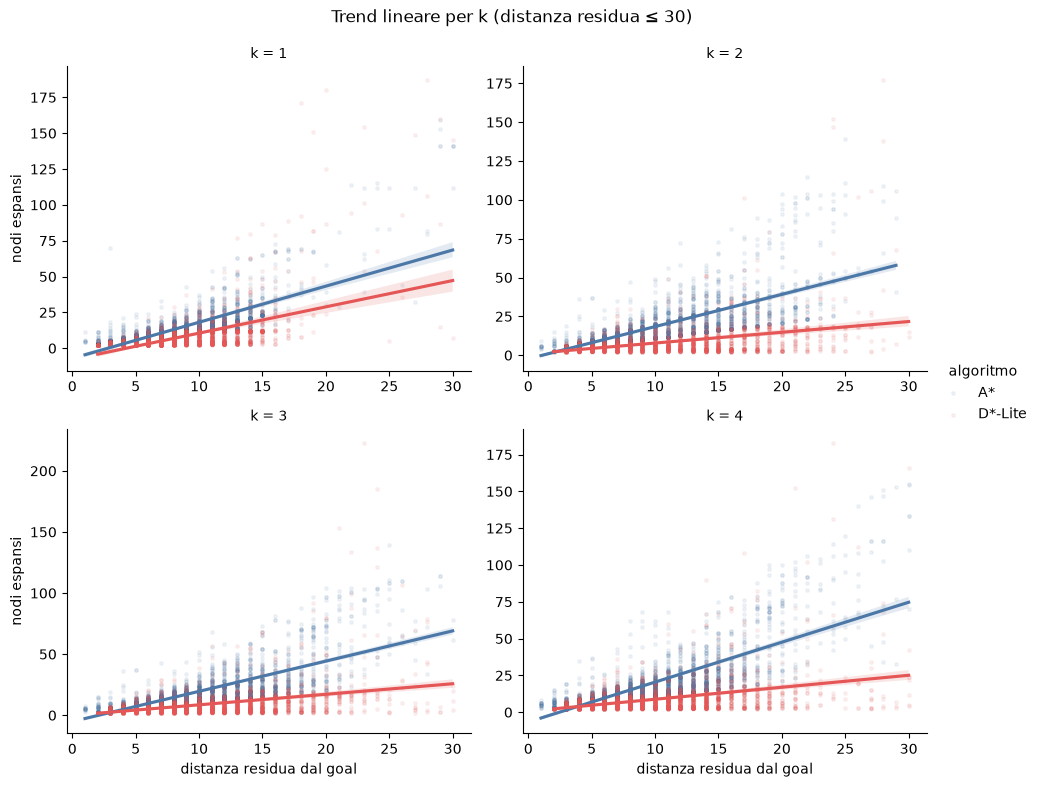

In [35]:
import seaborn as sns

# Eventi di replanning in forma lunga: una run rappresentativa per (maze, algo, k),
# perché gli eventi sono deterministici e le ripetute darebbero solo doppioni.
rep_runs = runs.reset_index().drop_duplicates(
    ["maze", "algorithm", "goal_count"])["run_id"]
ev_rows = []
for rid in rep_runs:
    log = raw_logs[rid]
    for e in log["replanning_events"]:
        ev_rows.append({
            "goal_count": log["goal_count"],
            "algoritmo": ALGO_LABEL[log["algorithm"]],
            "residual_distance": e["residual_distance"],
            "nodes_expanded": e["nodes_expanded"],
        })
events = pd.DataFrame(ev_rows)
events = events[events["residual_distance"] > 0]   # scarta -1 (inf) e 0

# Fascia densa: oltre ~30 gli eventi sono pochissimi, la coda non è affidabile.
RESIDUAL_MAX = 30
dense = events[events["residual_distance"] <= RESIDUAL_MAX]

grid = sns.lmplot(
    data=dense, x="residual_distance", y="nodes_expanded",
    hue="algoritmo", col="goal_count", col_wrap=2, order=1, ci=95,
    palette={"A*": ALGO_COLOR["astar"], "D*-Lite": ALGO_COLOR["dstar_lite"]},
    height=3.8, aspect=1.25, facet_kws={"sharey": False, "sharex": False},
    scatter_kws={"s": 6, "alpha": 0.08},
)
grid.set_axis_labels("distanza residua dal goal", "nodi espansi")
grid.set_titles("k = {col_name}")
grid.figure.suptitle(
    f"Trend lineare per k (distanza residua \u2264 {RESIDUAL_MAX})", y=1.03)
plt.show()

#### Aggregato su tutte le run

Stesso trend ma su **tutte le run insieme**, senza distinzione per k: una sola coppia
di rette di regressione (± banda 95%) riassume il comportamento complessivo dei due
algoritmi sulla fascia densa.

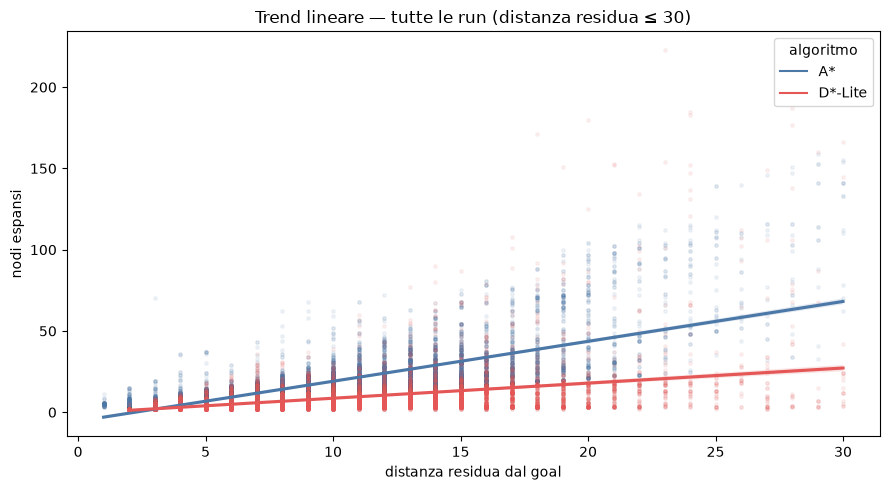

In [29]:
import matplotlib.lines as mlines

plt.figure(figsize=(9, 5))
for algo, label in ALGO_LABEL.items():
    sub = dense[dense["algoritmo"] == label]
    sns.regplot(data=sub, x="residual_distance", y="nodes_expanded", order=1, ci=95,
                color=ALGO_COLOR[algo], scatter_kws={"s": 6, "alpha": 0.08})
handles = [mlines.Line2D([], [], color=ALGO_COLOR[a], label=l)
           for a, l in ALGO_LABEL.items()]
plt.legend(handles=handles, title="algoritmo")
plt.xlabel("distanza residua dal goal")
plt.ylabel("nodi espansi")
plt.title(f"Trend lineare \u2014 tutte le run (distanza residua \u2264 {RESIDUAL_MAX})")
plt.tight_layout()
plt.show()

### Tabella di completezza — nodi espansi per fascia di distanza residua

Media e intervallo di confidenza al 95% dei nodi espansi, per fascia di distanza
residua e algoritmo, su **tutte le fasce** (comprese quelle escluse dalla
regressione). La colonna `nel_trend` indica le fasce usate nel fit (distanza
residua \u2264 `RESIDUAL_MAX`).

Si vede perché la coda è stata esclusa: oltre la soglia il numero di eventi `n`
crolla a poche decine e gli IC si allargano fino a sovrapporsi tra i due algoritmi
(es. fascia 35–40), mentre nelle fasce dense il divario è netto e con IC stretti.
IC calcolato con approssimazione normale (z = 1.96).

In [36]:
# Media e IC 95% (approssimazione normale, z=1.96) per fascia di distanza residua.
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, int(events["residual_distance"].max())]
ev_binned = events.assign(fascia=pd.cut(events["residual_distance"], bins))

tab_fasce = (ev_binned.groupby(["fascia", "algoritmo"], observed=True)["nodes_expanded"]
             .agg(n="size", media="mean", std="std").reset_index())
sem = tab_fasce["std"] / np.sqrt(tab_fasce["n"])
tab_fasce["ic95_low"] = (tab_fasce["media"] - 1.96 * sem).round(1)
tab_fasce["ic95_high"] = (tab_fasce["media"] + 1.96 * sem).round(1)
tab_fasce["media"] = tab_fasce["media"].round(1)
tab_fasce["nel_trend"] = tab_fasce["fascia"].apply(lambda f: f.right <= RESIDUAL_MAX)
tab_fasce = tab_fasce[["fascia", "algoritmo", "n", "media",
                       "ic95_low", "ic95_high", "nel_trend"]]
tab_fasce

,fascia,algoritmo,n,media,ic95_low,ic95_high,nel_trend
0,"(0, 5]",A*,2840,6.8,6.7,7.0,True
1,"(0, 5]",D*-Lite,2085,4.2,4.2,4.3,True
2,"(5, 10]",A*,4496,13.2,13.1,13.4,True
3,"(5, 10]",D*-Lite,3700,6.6,6.5,6.8,True
4,"(10, 15]",A*,2849,22.4,22.1,22.8,True
5,"(10, 15]",D*-Lite,2564,9.7,9.4,10.1,True
6,"(15, 20]",A*,908,37.2,35.9,38.5,True
7,"(15, 20]",D*-Lite,926,15.4,14.2,16.5,True
8,"(20, 25]",A*,249,62.1,58.4,65.8,True
9,"(20, 25]",D*-Lite,267,23.9,19.8,27.9,True


#### Versione markdown per la relazione

Pivot con A\* e D\*-Lite affiancati, pronto da incollare nel report (stampato come
testo così è copiabile).

In [37]:
# Tabella markdown: una riga per fascia, i due algoritmi affiancati.
def _fmt(r):
    return f"{r.media} [{r.ic95_low}, {r.ic95_high}] (n={r.n})"

_lines = ["| Distanza residua | A\\* — media [IC 95%] | D\\*-Lite — media [IC 95%] | Nel trend |",
          "|---|---|---|---|"]
for fascia in tab_fasce["fascia"].unique():
    sub = tab_fasce[tab_fasce["fascia"] == fascia]
    a = sub[sub.algoritmo == "A*"].iloc[0]
    d = sub[sub.algoritmo == "D*-Lite"].iloc[0]
    trend = "sì" if bool(a.nel_trend) else "no"
    _lines.append(f"| {fascia} | {_fmt(a)} | {_fmt(d)} | {trend} |")

tab_markdown = "\n".join(_lines)
print(tab_markdown)

| Distanza residua | A\* — media [IC 95%] | D\*-Lite — media [IC 95%] | Nel trend |
|---|---|---|---|
| (0, 5] | 6.8 [6.7, 7.0] (n=2840) | 4.2 [4.2, 4.3] (n=2085) | sì |
| (5, 10] | 13.2 [13.1, 13.4] (n=4496) | 6.6 [6.5, 6.8] (n=3700) | sì |
| (10, 15] | 22.4 [22.1, 22.8] (n=2849) | 9.7 [9.4, 10.1] (n=2564) | sì |
| (15, 20] | 37.2 [35.9, 38.5] (n=908) | 15.4 [14.2, 16.5] (n=926) | sì |
| (20, 25] | 62.1 [58.4, 65.8] (n=249) | 23.9 [19.8, 27.9] (n=267) | sì |
| (25, 30] | 93.3 [84.8, 101.8] (n=72) | 35.5 [26.6, 44.4] (n=98) | sì |
| (30, 35] | 122.3 [102.1, 142.6] (n=18) | 54.8 [32.9, 76.7] (n=44) | no |
| (35, 40] | 95.1 [73.5, 116.7] (n=12) | 89.5 [63.2, 115.9] (n=19) | no |
| (40, 59] | 99.9 [87.8, 112.1] (n=15) | 84.6 [55.3, 113.9] (n=17) | no |


## Nota metodologica — perché non facciamo analisi statistica inferenziale

Gli algoritmi (A\* e D\*-Lite), con il piazzamento dei goal fissato, sono
**deterministici**: rieseguendo la stessa run tutti gli scalari non-temporali —
mosse, `replanning_events`, `nodes_expanded`, `cost_ratio` — risultano **identici**
(verificato sui log ripetuti). Non c'è quindi alcuna variabilità stocastica da
stimare.

Di conseguenza **test d'ipotesi, p-value e intervalli di confidenza non si
applicano**: rispondono alla domanda *«questa differenza è dovuta al caso del
campionamento?»*, ma qui non c'è campionamento casuale. I nostri dati sono un
**censimento completo** dello spazio sperimentale (5 maze × 2 algoritmi × 4 valori
di k), non un campione estratto da una popolazione. Testare la «significatività» di
una differenza tra due numeri deterministici non ha senso.

Anche il **resampling** non aiuta:
- il **bootstrap** sui 5 maze li tratterebbe come estrazione casuale da «tutti i
  maze possibili», ma sono 5 labirinti specifici di competizione (n = 5):
  generalizzazione debolissima e non giustificata;
- un **permutation test** su dati appaiati e deterministici non ha nulla di
  informativo da permutare.

**L'unica fonte di rumore reale sono i tempi di macchina** (`execution_time_s`,
`cumulative_planning_time_s`), che oltretutto contengono outlier grossolani dovuti
al carico di sistema (es. una run a ~14 s contro ~0.04 s per lo stesso scenario).
Lì la statistica corretta è **descrittiva e robusta** — mediana e IQR sulle run
ripetute, outlier segnalati — non inferenza.

**Conclusione.** Ci fermiamo al livello adatto a questi dati: **statistica
descrittiva + confronto visivo appaiato** A\*/D\*-Lite sulle stesse coppie
(maze, k), più l'osservazione dei **trend** al crescere di k e della complessità del
maze. Niente p-value, niente resampling.